In [1]:
# ============================================
# 02_exploratory_analysis.ipynb
# Project: Customer Churn Analysis
# Purpose: Deeper exploration of churn patterns
#          Correlation analysis, distributions, and multi-variable visualisations
# ============================================

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Visualisation style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Load data from PostgreSQL
load_dotenv()
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
df = pd.read_sql('SELECT * FROM telco', engine)

# Apply same cleaning as notebook 01
df['totalcharges'] = pd.to_numeric(
    df['totalcharges'].str.strip(), errors='coerce'
).fillna(0)
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
df.columns = df.columns.str.lower().str.strip()
df = df.drop('customerid', axis=1)

print(f"Data loaded and cleaned — {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded and cleaned — 7043 rows, 20 columns


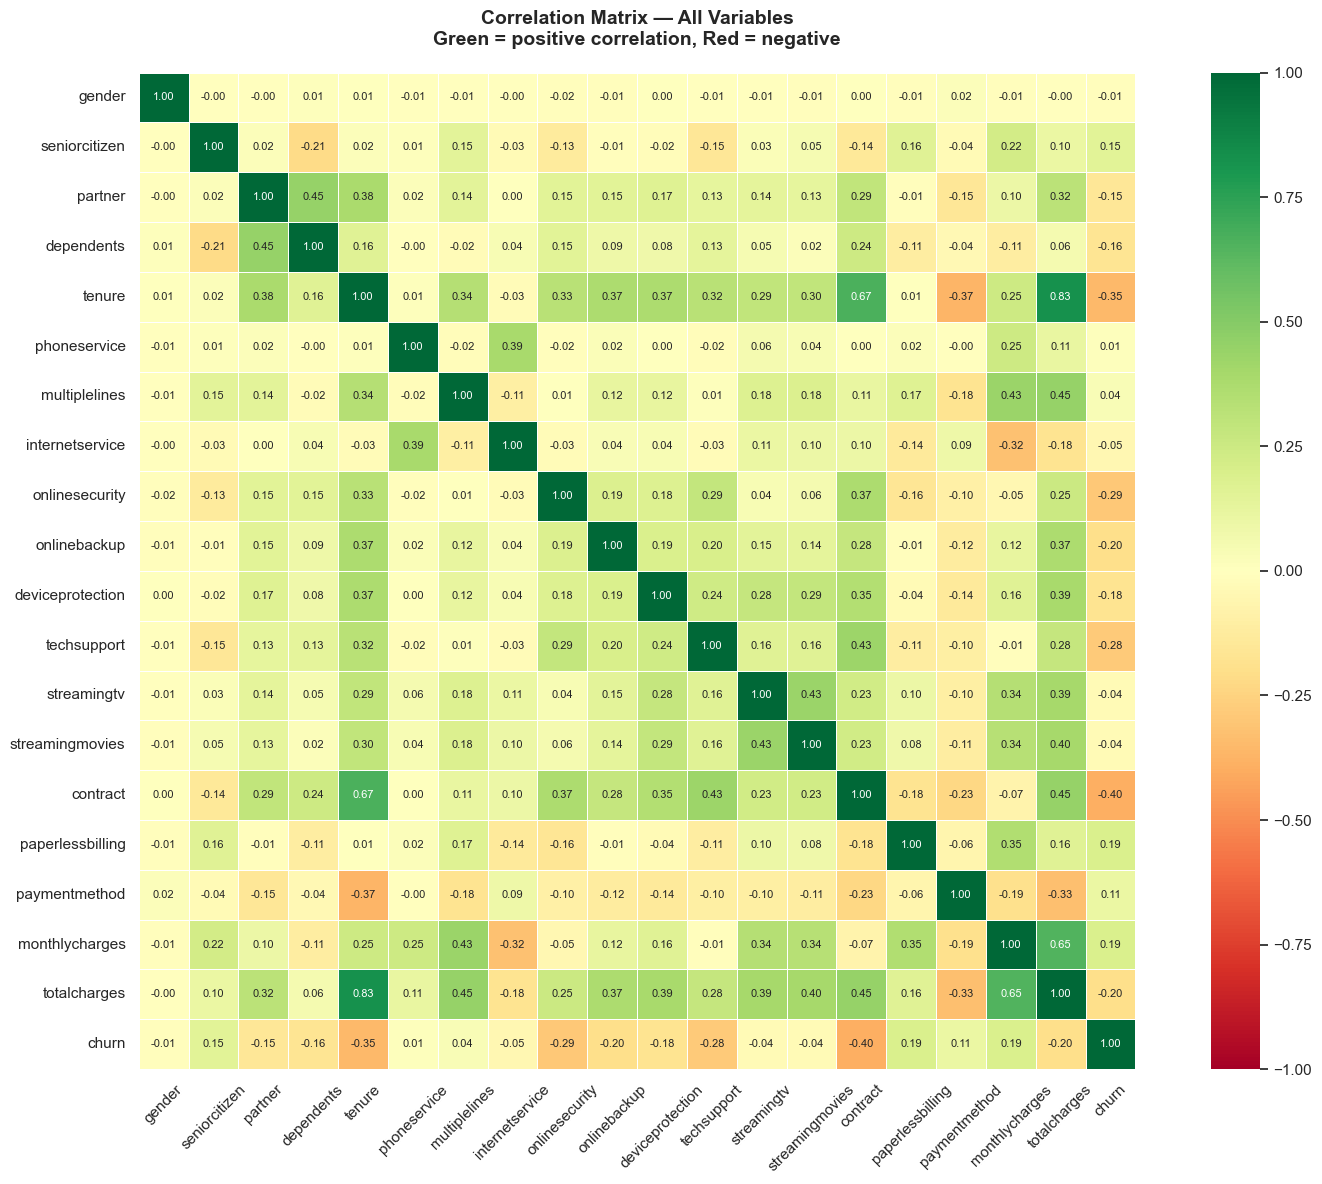

Correlation heatmap saved


In [2]:
# ============================================
# Cell 2: Correlation Heatmap
# Purpose: See all variable relationships at once
# Which features correlate most with churn?
# ============================================

# --- Prepare data ---
# Encode categorical columns as numbers
# Correlation only works on numeric data
df_encoded = df.copy()

# Label encode all object columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_columns = df_encoded.select_dtypes(include='object').columns
for col in cat_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Calculate correlation matrix
corr_matrix = df_encoded.corr()

# --- Build heatmap ---
fig, ax = plt.subplots(figsize=(16, 12))

# Generate heatmap
sns.heatmap(
    corr_matrix,
    annot=True,                    # show numbers in cells
    fmt='.2f',                     # 2 decimal places
    cmap='RdYlGn',                 # red=negative, green=positive
    center=0,                      # white at zero correlation
    vmin=-1, vmax=1,               # correlation range
    square=True,                   # square cells
    linewidths=0.5,                # cell borders
    linecolor='white',
    annot_kws={'size': 8},         # annotation font size
    ax=ax
)

ax.set_title(
    'Correlation Matrix — All Variables\n'
    'Green = positive correlation, Red = negative',
    pad=20
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/07_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved")

=== CORRELATION WITH CHURN ===
monthlycharges      0.193356
paperlessbilling    0.191825
seniorcitizen       0.150889
paymentmethod       0.107062
multiplelines       0.038037
phoneservice        0.011942
gender             -0.008612
streamingtv        -0.036581
streamingmovies    -0.038492
internetservice    -0.047291
partner            -0.150448
dependents         -0.164221
deviceprotection   -0.178134
onlinebackup       -0.195525
totalcharges       -0.198324
techsupport        -0.282492
onlinesecurity     -0.289309
tenure             -0.352229
contract           -0.396713


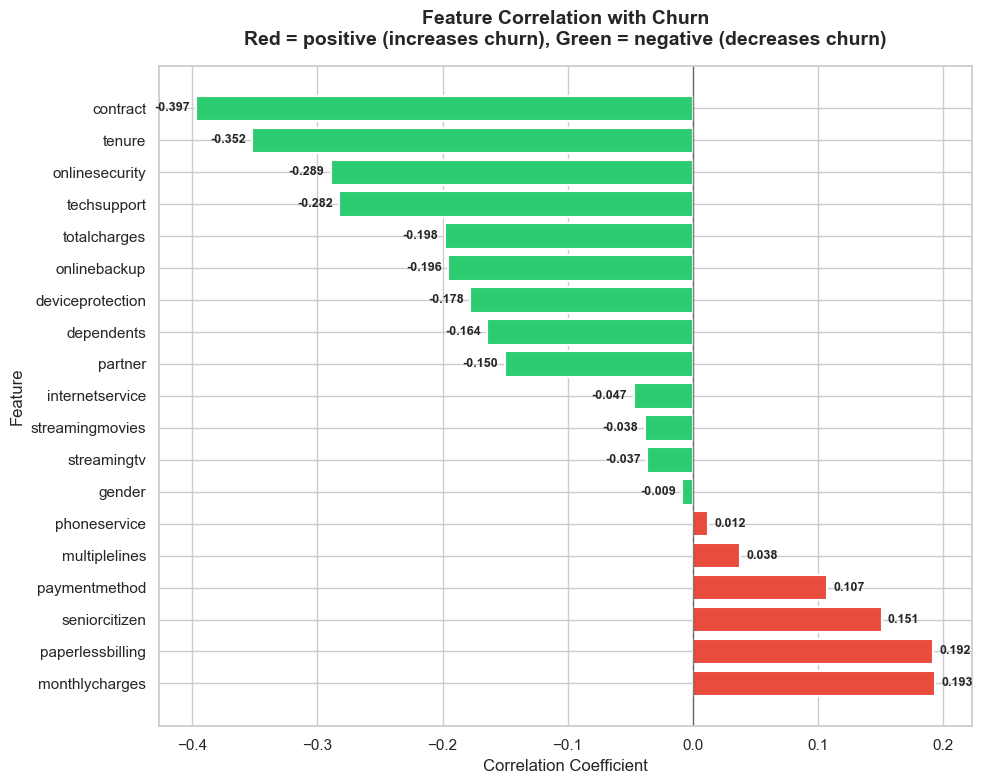

In [3]:
# ============================================
# Cell 3: Churn Correlation Ranking
# Purpose: Which variables correlate most strongly with churn specifically?
# ============================================

# Extract just the churn column correlations
churn_corr = corr_matrix['churn'].drop('churn')
churn_corr = churn_corr.sort_values(ascending=False)

print("=== CORRELATION WITH CHURN ===")
print(churn_corr.to_string())

# Visualise as horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if x > 0 else '#2ecc71'
          for x in churn_corr.values]

bars = ax.barh(
    churn_corr.index,
    churn_corr.values,
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

# Add value labels
for bar, value in zip(bars, churn_corr.values):
    ax.text(
        value + (0.005 if value >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        ha='left' if value >= 0 else 'right',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# Add zero reference line
ax.axvline(x=0, color='black', linewidth=1, alpha=0.5)

ax.set_title(
    'Feature Correlation with Churn\n'
    'Red = positive (increases churn), '
    'Green = negative (decreases churn)',
    pad=15
)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig('../outputs/figures/08_churn_correlation_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ============================================
# Cell 4: Correlation Findings Summary
# Documents key insights from correlation analysis
# Informs feature selection for ML model
# ============================================

print("=" * 50)
print("CORRELATION ANALYSIS — KEY FINDINGS")
print("=" * 50)

print("\n📊 STRONGEST PREDICTORS OF CHURN:")
print(f"  contract:         {churn_corr['contract']:.3f}  — strongest single predictor")
print(f"  tenure:           {churn_corr['tenure']:.3f}  — second strongest predictor")
print(f"  onlinesecurity:   {churn_corr['onlinesecurity']:.3f}  — strongest protective factor")
print(f"  techsupport:      {churn_corr['techsupport']:.3f}  — second protective factor")
print(f"  monthlycharges:   {churn_corr['monthlycharges']:.3f}  — higher bills = more churn")
print(f"  paperlessbilling: {churn_corr['paperlessbilling']:.3f}  — digital customers churn more")

print("\n🚫 FEATURES TO DROP FROM ML MODEL:")
print(f"  gender:           {churn_corr['gender']:.3f}  — near zero, no predictive value")
print(f"  phoneservice:     {churn_corr['phoneservice']:.3f}  — near zero, no predictive value")

print("\n💡 SURPRISING FINDINGS:")
print("  1. paperlessbilling +0.192 — digital customers more likely to churn — similar psychology to electronic check")
print("  2. Add-on services reduce churn more than any demographic factor — onlinesecurity and techsupport are stickiest")
print("  3. gender is irrelevant to churn — drop from ML model")
print("  4. Contract is 2x stronger predictor than tenure — commitment level matters more than time with company")

print("\n✅ FEATURES SELECTED FOR ML MODEL:")
ml_features = [
    col for col in churn_corr.index
    if col not in ['gender', 'phoneservice']
]
for i, feature in enumerate(ml_features, 1):
    print(f"  {i:2}. {feature:<20} {churn_corr[feature]:.3f}")

print(f"\n  Total features selected: {len(ml_features)}")
print(f"  Features dropped: gender, phoneservice")
print("=" * 50)

CORRELATION ANALYSIS — KEY FINDINGS

📊 STRONGEST PREDICTORS OF CHURN:
  contract:         -0.397  — strongest single predictor
  tenure:           -0.352  — second strongest predictor
  onlinesecurity:   -0.289  — strongest protective factor
  techsupport:      -0.282  — second protective factor
  monthlycharges:   0.193  — higher bills = more churn
  paperlessbilling: 0.192  — digital customers churn more

🚫 FEATURES TO DROP FROM ML MODEL:
  gender:           -0.009  — near zero, no predictive value
  phoneservice:     0.012  — near zero, no predictive value

💡 SURPRISING FINDINGS:
  1. paperlessbilling +0.192 — digital customers more likely to churn — similar psychology to electronic check
  2. Add-on services reduce churn more than any demographic factor — onlinesecurity and techsupport are stickiest
  3. gender is irrelevant to churn — drop from ML model
  4. Contract is 2x stronger predictor than tenure — commitment level matters more than time with company

✅ FEATURES SELECTED FO